# Сравнение методов минимизации: координатный спуск против градиентного

Сравниваем две «лучшие» реализации на **одних и тех же 16 тестовых случаях**:

1. **покоординатный спуск** с методом Брента как одномерным шагом — без производных, использует
   только значения `f`;
2. **градиентный спуск, метод Ньютона + backtracking** — использует градиент и Гессиан;
3. промежуточный ориентир — **градиентный спуск первого порядка с фиксированным шагом**
   (`a = 1/λmax`, где `λmax` — наибольшее собственное число Гессиана в стартовой точке).

Все методы стартуют из центра прямоугольника поиска, сверяются с эталонным минимумом с допуском
`ATOL = 0.05`.

**Метрика сравнения — число вызовов целевой функции `f`** (итерации у методов означают разное).
Важная оговорка: координатному спуску производные не нужны вовсе, а градиентным — нужны градиент
(и Гессиан у Ньютона). Эти производные в таблице не входят в счётчик `f`, но бесплатными не являются —
при честном подсчёте их стоимость нужно добавлять отдельно.


In [1]:
import math


def make_func_along_x(f, y_fixed):
    def g(x):
        return f(x, y_fixed)
    return g


def make_func_along_y(f, x_fixed):
    def h(y):
        return f(x_fixed, y)
    return h


def brent(f, a, b, eps=1e-3, max_iter=100):
    c_gold = (3 - math.sqrt(5)) / 2
    x = w = v = a + c_gold * (b - a)
    fx = fw = fv = f(x)
    d = 0
    e = 0
    func_calls = 1
    for iteration in range(max_iter):
        if (b - a) < eps:
            break
        u = None
        if e != 0 and v != w and w != x and v != x:
            D1 = (fw - fx) / (w - x)
            D2 = (fv - fw) / (v - w)
            A = (D2 - D1) / (v - x)
            if abs(A) > 1e-12:
                apex = (x + w) / 2 - D1 / (2 * A)
                if a < apex < b and abs(apex - x) < 0.5 * abs(e):
                    u = apex
        if u is None:
            if x < (a + b) / 2:
                u = x + (b - x) * c_gold
            else:
                u = x - (x - a) * c_gold
        e = d
        d = u - x
        fu = f(u)
        func_calls += 1
        if fu <= fx:
            if u >= x:
                a = x
            else:
                b = x
            v, fv = w, fw
            w, fw = x, fx
            x, fx = u, fu
        else:
            if u >= x:
                b = u
            else:
                a = u
            if fu <= fw or w == x:
                v, fv = w, fw
                w, fw = u, fu
            elif fu <= fv or v == x or v == w:
                v, fv = u, fu
    return x, fx, func_calls, iteration


def coordinate_descent_brent(f, bounds, eps=1e-3, max_iter=1000):
    x = (bounds[0][0] + bounds[0][1]) / 2
    y = (bounds[1][0] + bounds[1][1]) / 2
    converged = False
    iteration_count = 0
    func_calls = 0

    def counted_1d(g):
        def wrapper(x):
            nonlocal func_calls
            func_calls += 1
            return g(x)
        return wrapper

    for iteration in range(max_iter):
        x_old, y_old = x, y
        x_bounds, y_bounds = bounds[0], bounds[1]
        g_x = make_func_along_x(f, y)
        x, _, _, _ = brent(counted_1d(g_x), x_bounds[0], x_bounds[1], eps)
        h_y = make_func_along_y(f, x)
        y, _, _, _ = brent(counted_1d(h_y), y_bounds[0], y_bounds[1], eps)
        iteration_count += 1
        if abs(x - x_old) < eps and abs(y - y_old) < eps:
            converged = True
            break
    return x, y, converged, iteration_count, func_calls


In [2]:
def numerical_hessian(f, x1, x2, h=1e-5):
    f0 = f(x1, x2)
    f_xx = (f(x1 + h, x2) - 2 * f0 + f(x1 - h, x2)) / h**2
    f_yy = (f(x1, x2 + h) - 2 * f0 + f(x1, x2 - h)) / h**2
    f_xy = (f(x1 + h, x2 + h) - f(x1 + h, x2 - h) - f(x1 - h, x2 + h) + f(x1 - h, x2 - h)) / (4 * h**2)
    return [[f_xx, f_xy], [f_xy, f_yy]]


def gradient_descent_2d_analit(f, f1, x1, x2, a=0.01, eps=1e-3, max_iter=100, guard=True):
    x = [x1, x2]
    f_x = f(x[0], x[1])
    func_calls = 1
    history_x = [(x1, x2)]
    history_f = [f_x]
    for iteration in range(max_iter):
        grad = f1(x[0], x[1])
        x_new1 = x[0] - a * grad[0]
        x_new2 = x[1] - a * grad[1]
        f_new = f(x_new1, x_new2)
        func_calls += 1
        if guard and f_new > f_x:
            return x[0], x[1], f_x, iteration + 1, func_calls, history_x, history_f, False
        grad_norm = math.hypot(grad[0], grad[1])
        if grad_norm < eps:
            history_x.append((x_new1, x_new2))
            history_f.append(f_new)
            return x_new1, x_new2, f_new, iteration + 1, func_calls, history_x, history_f, True
        x = [x_new1, x_new2]
        f_x = f_new
        history_x.append((x_new1, x_new2))
        history_f.append(f_x)
    return x[0], x[1], f_x, iteration + 1, func_calls, history_x, history_f, False


def gradient_descent_backtrack2D(f, f1, x1, x2, eps=1e-3, max_iter=100, h=1e-4, f2=None):
    x = [x1, x2]
    f_x = f(x[0], x[1])
    func_calls = 1
    history_x = [(x[0], x[1])]
    history_f = [f_x]
    for iteration in range(max_iter):
        grad = f1(x[0], x[1])
        if f2 is not None:
            H = f2(x[0], x[1])
        else:
            H = numerical_hessian(f, x[0], x[1], h=h)
            func_calls += 9
        h11, h12 = H[0][0], H[0][1]
        h21, h22 = H[1][0], H[1][1]
        det = h11 * h22 - h12 * h21
        if h11 <= 0 or det <= 0:
            return (x[0], x[1], f_x, iteration + 1, func_calls, history_x, history_f, False)
        if det < 1e-12:
            return (x[0], x[1], f_x, iteration + 1, func_calls, history_x, history_f, False)
        step1 = (grad[0] * h22 - grad[1] * h12) / det
        step2 = (h11 * grad[1] - h21 * grad[0]) / det
        if not (math.isfinite(step1) and math.isfinite(step2)):
            return (x[0], x[1], f_x, iteration + 1, func_calls, history_x, history_f, False)
        t = 1.0
        x_new1 = x[0] - t * step1
        x_new2 = x[1] - t * step2
        f_new = f(x_new1, x_new2)
        func_calls += 1
        while f_new > f_x:
            t *= 0.5
            if t < 1e-12:
                return (x[0], x[1], f_x, iteration + 1, func_calls, history_x, history_f, False)
            x_new1 = x[0] - t * step1
            x_new2 = x[1] - t * step2
            f_new = f(x_new1, x_new2)
            func_calls += 1
        grad_norm = math.hypot(grad[0], grad[1])
        if grad_norm < eps:
            history_x.append((x_new1, x_new2))
            history_f.append(f_new)
            return x_new1, x_new2, f_new, iteration + 1, func_calls, history_x, history_f, True
        x = [x_new1, x_new2]
        f_x = f_new
        history_x.append((x_new1, x_new2))
        history_f.append(f_x)
    return x[0], x[1], f_x, iteration + 1, func_calls, history_x, history_f, False


In [3]:
# ================== 16 тестовых случаев ==================
R5 = [[-5.0, 5.0], [-5.0, 5.0]]

def q23(x, y): return (x - 2)**2 + (y - 3)**2
def gq23(x, y): return [2*x - 4, 2*y - 6]
def hq23(x, y): return [[2.0, 0.0], [0.0, 2.0]]

def q4(x, y): return (x - 4)**2 + (y + 4)**2
def gq4(x, y): return [2*x - 8, 2*y + 8]
def hq4(x, y): return [[2.0, 0.0], [0.0, 2.0]]

def rot(x, y): return (x + y - 1)**2 + (x - y)**2
def grot(x, y): return [4*x - 2, 4*y - 2]
def hrot(x, y): return [[4.0, 0.0], [0.0, 4.0]]

def par(x, y): return x**2 + y**2
def gpar(x, y): return [2*x, 2*y]
def hpar(x, y): return [[2.0, 0.0], [0.0, 2.0]]

def parrot(x, y):
    u1 = 2*x + y + 1; u2 = -x + 1.5*y - 2
    return u1**2 + u2**2
def gparrot(x, y):
    u1 = 2*x + y + 1; u2 = -x + 1.5*y - 2
    return [4*u1 - 2*u2, 2*u1 + 3*u2]
def hparrot(x, y): return [[10.0, 1.0], [1.0, 6.5]]

def rosen(x, y): return (1 - x)**2 + 100*(y - x**2)**2
def grosen(x, y): return [-2*(1 - x) - 400*x*(y - x**2), 200*(y - x**2)]
def hrosen(x, y): return [[2 - 400*y + 1200*x**2, -400*x], [-400*x, 200.0]]

def t1(u, v): return 32/v + 64/u + 2*u*v
def g1(u, v): return [-64/u**2 + 2*v, -32/v**2 + 2*u]
def h1(u, v): return [[128/u**3, 2.0], [2.0, 64/v**3]]

def t2(a, b): return -(54*a*b - a**2*b - a*b**2)
def g2(a, b): return [-54*b + 2*a*b + b**2, -54*a + a**2 + 2*a*b]
def h2(a, b): return [[2*b, -54 + 2*a + 2*b], [-54 + 2*a + 2*b, 2*a]]

POINTS = [(1, 2), (2, 2), (3, 4), (4, 5), (5, 6)]
def t3(k, b): return sum((k*x + b - y)**2 for x, y in POINTS)
def g3(k, b):
    return [2*sum(x*(k*x + b - y) for x, y in POINTS),
            2*sum((k*x + b - y) for x, y in POINTS)]
def h3(k, b): return [[110.0, 30.0], [30.0, 10.0]]

def t4(x, y):
    return math.hypot(x, y) + math.hypot(x - 8, y) + math.hypot(x - 4, y - 6)
def g4(x, y):
    gx = gy = 0.0
    for px, py in [(0, 0), (8, 0), (4, 6)]:
        r = math.hypot(x - px, y - py); gx += (x - px)/r; gy += (y - py)/r
    return [gx, gy]
def h4(x, y):
    A = B = C = 0.0
    for px, py in [(0, 0), (8, 0), (4, 6)]:
        dx, dy = x - px, y - py; r = math.hypot(dx, dy)
        A += dy**2/r**3; C += dx**2/r**3; B += -dx*dy/r**3
    return [[A, B], [B, C]]

def t5(x, y): return -(40*x + 50*y - x**2 - y**2 - x*y)
def g5(x, y): return [-40 + 2*x + y, -50 + 2*y + x]
def h5(x, y): return [[2.0, 1.0], [1.0, 2.0]]

def t7(x1, x2):
    return (math.sqrt(4 + x1**2)/4 + math.sqrt((x2 - x1)**2 + 9)/2
            + math.sqrt((10 - x2)**2 + 4)/3)
def g7(x1, x2):
    d = x2 - x1
    return [x1/(4*math.sqrt(4 + x1**2)) - d/(2*math.sqrt(d**2 + 9)),
            d/(2*math.sqrt(d**2 + 9)) - (10 - x2)/(3*math.sqrt((10 - x2)**2 + 4))]
def h7(x1, x2):
    d = x2 - x1; e = 10 - x2; B = 9/(2*(d**2 + 9)**1.5)
    return [[1/(4 + x1**2)**1.5 + B, -B], [-B, B + 4/(3*(e**2 + 4)**1.5)]]

def t8(u, v): return -(6*u*v - 1.5*u**2*v - 2*u*v**2)
def g8(u, v): return [-6*v + 3*u*v + 2*v**2, -6*u + 1.5*u**2 + 4*u*v]
def h8(u, v): return [[3*v, -6 + 3*u + 4*v], [-6 + 3*u + 4*v, 4*u]]

def t9(x, y): return x**3 + y**3 - 3*x*y
def g9(x, y): return [3*x**2 - 3*y, 3*y**2 - 3*x]
def h9(x, y): return [[6*x, -3.0], [-3.0, 6*y]]

# (название, f, grad, hess, прямоугольник, эталон)
CASES = [
    ("quad (x-2)^2+(y-3)^2", q23, gq23, hq23, R5, (2.0, 3.0)),
    ("quad (x-4)^2+(y+4)^2", q4, gq4, hq4, R5, (4.0, -4.0)),
    ("повёрнутая quad", rot, grot, hrot, R5, (0.5, 0.5)),
    ("параболоид", par, gpar, hpar, R5, (0.0, 0.0)),
    ("параболоид повёрнутый", parrot, gparrot, hparrot, R5, (-0.875, 0.75)),
    ("Розенброк", rosen, grosen, hrosen, R5, (1.0, 1.0)),
    ("1. Аквариум", t1, g1, h1, [[0.0, 5.0], [0.0, 5.0]], (4.0, 2.0)),
    ("2. Посылка", t2, g2, h2, [[0.0, 40.0], [0.0, 40.0]], (18.0, 18.0)),
    ("3. МНК", t3, g3, h3, [[-2.0, 3.0], [-2.0, 3.0]], (1.1, 0.5)),
    ("4. Склад", t4, g4, h4, [[0.0, 8.0], [0.0, 6.0]], (4.0, 4/math.sqrt(3))),
    ("5. Два товара", t5, g5, h5, [[0.0, 30.0], [0.0, 30.0]], (10.0, 20.0)),
    ("7. Три слоя", t7, g7, h7, [[0.0, 10.0], [0.0, 10.0]], (6.3252, 7.9526)),
    ("8. Ящик", t8, g8, h8, [[0.0, 2.5], [0.5, 1.5]], (4/3, 1.0)),
    ("9. Температура", t9, g9, h9, [[0.5, 1.5], [0.5, 1.5]], (1.0, 1.0)),
    ("9b. седло внутри", t9, g9, h9, [[-0.4, 2.0], [-0.4, 2.0]], (1.0, 1.0)),
    ("9c. старт в седле", t9, g9, h9, [[-2.0, 2.0], [-2.0, 2.0]], (-2.0, -2.0)),
]


Assert-блок: все проверки пройдены.

коорд. спуск (Брент)  : OK 15/16, суммарно вызовов f = 7653
градиент фикс. шаг    : OK 14/16, суммарно вызовов f = 796
градиент backtrack    : OK 15/16, суммарно вызовов f = 73



| Случай | Метод | x | y | f | Итераций | Вызовов f | Статус |
|:---|:---|:---:|:---:|:---:|:---:|:---:|:---|
| quad (x-2)^2+(y-3)^2 | коорд. спуск (Брент) | 2.0000 | 3.0000 | 0.0000 | 2 | 31 | OK |
| quad (x-2)^2+(y-3)^2 | градиент фикс. шаг | 2.0000 | 3.0000 | 0.0000 | 2 | 3 | OK |
| quad (x-2)^2+(y-3)^2 | градиент backtrack | 2.0000 | 3.0000 | 0.0000 | 2 | 3 | OK |
| quad (x-4)^2+(y+4)^2 | коорд. спуск (Брент) | 4.0000 | -4.0000 | 0.0000 | 2 | 47 | OK |
| quad (x-4)^2+(y+4)^2 | градиент фикс. шаг | 4.0000 | -4.0000 | 0.0000 | 2 | 3 | OK |
| quad (x-4)^2+(y+4)^2 | градиент backtrack | 4.0000 | -4.0000 | 0.0000 | 2 | 3 | OK |
| повёрнутая quad | коорд. спуск (Брент) | 0.5000 | 0.5000 | 0.0000 | 2 | 50 | OK |
| повёрнутая quad | градиент фикс. шаг | 0.5000 | 0.5000 | 0.0000 | 2 | 3 | OK |
| повёрнутая quad | градиент backtrack | 0.5000 | 0.5000 | 0.0000 | 2 | 3 | OK |
| параболоид | коорд. спуск (Брент) | 0.0000 | 0.0000 | 0.0000 | 1 | 22 | OK |
| параболоид | градиент фикс. шаг | 0.0000 | 0.0000 | 0.0000 | 1 | 2 | OK |
| параболоид | градиент backtrack | 0.0000 | 0.0000 | 0.0000 | 1 | 2 | OK |
| параболоид повёрнутый | коорд. спуск (Брент) | -0.8750 | 0.7500 | 0.0000 | 4 | 66 | OK |
| параболоид повёрнутый | градиент фикс. шаг | -0.8750 | 0.7500 | 0.0000 | 11 | 12 | OK |
| параболоид повёрнутый | градиент backtrack | -0.8750 | 0.7500 | 0.0000 | 2 | 3 | OK |
| Розенброк | коорд. спуск (Брент) | 0.8337 | 0.6950 | 0.0277 | 247 | 6219 | не сошлось |
| Розенброк | градиент фикс. шаг | 0.6648 | 0.4436 | 0.1126 | 194 | 195 | не сошлось |
| Розенброк | градиент backtrack | 1.0000 | 1.0000 | 0.0000 | 13 | 19 | OK |
| 1. Аквариум | коорд. спуск (Брент) | 3.9999 | 2.0000 | 48.0000 | 7 | 153 | OK |
| 1. Аквариум | градиент фикс. шаг | 3.9995 | 2.0001 | 48.0000 | 44 | 45 | OK |
| 1. Аквариум | градиент backtrack | 4.0000 | 2.0000 | 48.0000 | 5 | 6 | OK |
| 2. Посылка | коорд. спуск (Брент) | 17.9998 | 18.0001 | -5832.0000 | 7 | 185 | OK |
| 2. Посылка | градиент фикс. шаг | 18.0000 | 18.0000 | -5832.0000 | 8 | 9 | OK |
| 2. Посылка | градиент backtrack | 18.0000 | 18.0000 | -5832.0000 | 4 | 5 | OK |
| 3. МНК | коорд. спуск (Брент) | 1.1000 | 0.5000 | 0.7000 | 2 | 43 | OK |
| 3. МНК | градиент фикс. шаг | 1.0998 | 0.5006 | 0.7000 | 391 | 392 | OK |
| 3. МНК | градиент backtrack | 1.1000 | 0.5000 | 0.7000 | 2 | 4 | OK |
| 4. Склад | коорд. спуск (Брент) | 4.0000 | 2.3094 | 12.9282 | 2 | 37 | OK |
| 4. Склад | градиент фикс. шаг | 4.0000 | 2.3097 | 12.9282 | 7 | 8 | OK |
| 4. Склад | градиент backtrack | 4.0000 | 2.3094 | 12.9282 | 3 | 4 | OK |
| 5. Два товара | коорд. спуск (Брент) | 10.0002 | 19.9999 | -700.0000 | 8 | 202 | OK |
| 5. Два товара | градиент фикс. шаг | 10.0004 | 19.9996 | -700.0000 | 23 | 24 | OK |
| 5. Два товара | градиент backtrack | 10.0000 | 20.0000 | -700.0000 | 2 | 3 | OK |
| 7. Три слоя | коорд. спуск (Брент) | 6.3251 | 7.9527 | 4.3190 | 19 | 362 | OK |
| 7. Три слоя | градиент фикс. шаг | 6.3012 | 7.9336 | 4.3190 | 62 | 63 | OK |
| 7. Три слоя | градиент backtrack | 6.3268 | 7.9539 | 4.3190 | 4 | 6 | OK |
| 8. Ящик | коорд. спуск (Брент) | 1.3333 | 1.0000 | -2.6667 | 2 | 43 | OK |
| 8. Ящик | градиент фикс. шаг | 1.3331 | 1.0001 | -2.6667 | 15 | 16 | OK |
| 8. Ящик | градиент backtrack | 1.3333 | 1.0000 | -2.6667 | 3 | 4 | OK |
| 9. Температура | коорд. спуск (Брент) | 1.0000 | 1.0000 | -1.0000 | 1 | 18 | OK |
| 9. Температура | градиент фикс. шаг | 1.0000 | 1.0000 | -1.0000 | 1 | 2 | OK |
| 9. Температура | градиент backtrack | 1.0000 | 1.0000 | -1.0000 | 1 | 2 | OK |
| 9b. седло внутри | коорд. спуск (Брент) | 0.9999 | 0.9999 | -1.0000 | 6 | 99 | OK |
| 9b. седло внутри | градиент фикс. шаг | 0.9999 | 0.9999 | -1.0000 | 16 | 17 | OK |
| 9b. седло внутри | градиент backtrack | 1.0000 | 1.0000 | -1.0000 | 4 | 5 | OK |
| 9c. старт в седле | коорд. спуск (Брент) | -1.9996 | -1.9996 | -27.9846 | 2 | 76 | OK |
| 9c. старт в седле | градиент фикс. шаг | 0.0000 | 0.0000 | 0.0000 | 1 | 2 | не сошлось |
| 9c. старт в седле | градиент backtrack | 0.0000 | 0.0000 | 0.0000 | 1 | 1 | не сошлось |

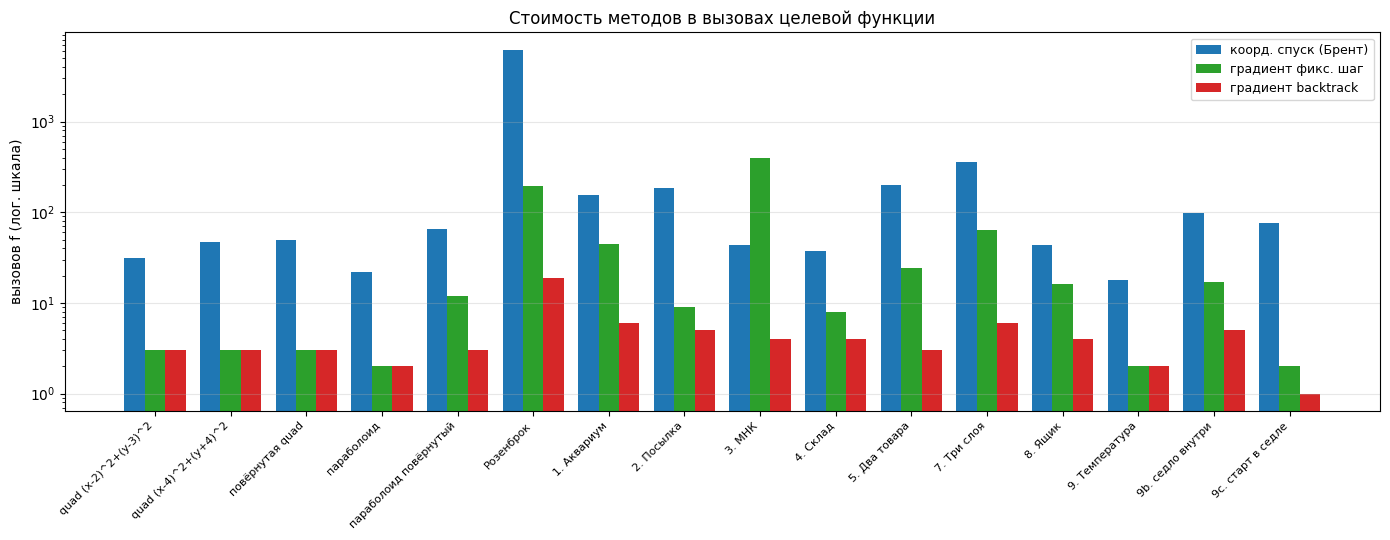

In [4]:
import numpy as np
import matplotlib.pyplot as plt

ATOL = 0.05
METHODS = ["коорд. спуск (Брент)", "градиент фикс. шаг", "градиент backtrack"]


def lambda_max(H):
    tr = H[0][0] + H[1][1]
    det = H[0][0] * H[1][1] - H[0][1] * H[1][0]
    disc = max(tr * tr - 4 * det, 0.0)
    return (tr + math.sqrt(disc)) / 2


records = []
for name, f, g, h, bounds, ref in CASES:
    x0 = (bounds[0][0] + bounds[0][1]) / 2
    y0 = (bounds[1][0] + bounds[1][1]) / 2

    xc, yc, cc, itc, clc = coordinate_descent_brent(f, bounds)
    runs = [("коорд. спуск (Брент)", xc, yc, cc, itc, clc)]

    lm = lambda_max(h(x0, y0))
    a = 1.0 / lm if lm > 1e-9 else 0.1
    xf, yf, ff, itf, clf, _, _, okf = gradient_descent_2d_analit(f, g, x0, y0, a=a, max_iter=500)
    runs.append(("градиент фикс. шаг", xf, yf, okf, itf, clf))

    xb, yb, fb, itb, clb, _, _, okb = gradient_descent_backtrack2D(f, g, x0, y0, f2=h, max_iter=500)
    runs.append(("градиент backtrack", xb, yb, okb, itb, clb))

    for mname, x, y, ok, it, cl in runs:
        err = max(abs(x - ref[0]), abs(y - ref[1]))
        if err < ATOL and ok:
            status = "OK"
        elif err < ATOL:
            status = "точка верна, флаг False"
        else:
            status = "не сошлось"
        records.append(dict(task=name, method=mname, x=x, y=y, fv=f(x, y),
                            it=it, calls=cl, err=err, status=status))


# ---------- assert-блок ----------
def get(task, method):
    return next(r for r in records if r["task"] == task and r["method"] == method)

# координатный спуск сходится везде, кроме овражной функции Розенброка
for r in records:
    if r["method"] == "коорд. спуск (Брент)" and r["task"] != "Розенброк":
        assert r["status"] == "OK", f"coord: {r['task']} -> {r['status']}"

# backtrack сходится везде, кроме старта в седле (Гессиан не положительно определён)
for r in records:
    if r["method"] == "градиент backtrack" and r["task"] != "9c. старт в седле":
        assert r["status"] == "OK", f"backtrack: {r['task']} -> {r['status']}"

# контраст на овражной функции: Ньютон доходит, покоординатный спуск — нет
assert get("Розенброк", "градиент backtrack")["status"] == "OK"
assert get("Розенброк", "коорд. спуск (Брент)")["status"] == "не сошлось"

# контраст на седле: покоординатный спуск уходит в угол, Ньютон отказывает
assert get("9c. старт в седле", "коорд. спуск (Брент)")["status"] == "OK"
assert get("9c. старт в седле", "градиент backtrack")["status"] == "не сошлось"

# Ньютон радикально дешевле по вызовам f
tc = sum(r["calls"] for r in records if r["method"] == "коорд. спуск (Брент)")
tb = sum(r["calls"] for r in records if r["method"] == "градиент backtrack")
assert tb < tc / 10, f"ожидалось, что backtrack на порядок дешевле: {tb} vs {tc}"

print("Assert-блок: все проверки пройдены.\n")

# ---------- сводка ----------
for m in METHODS:
    sub = [r for r in records if r["method"] == m]
    ok = sum(1 for r in sub if r["status"] == "OK")
    calls = sum(r["calls"] for r in sub)
    print(f"{m:22s}: OK {ok}/{len(sub)}, суммарно вызовов f = {calls}")
print()

# ---------- таблица ----------
from IPython.display import Markdown, display

lines = [
    "| Случай | Метод | x | y | f | Итераций | Вызовов f | Статус |",
    "|:---|:---|:---:|:---:|:---:|:---:|:---:|:---|",
]
for name, *_ in CASES:
    for m in METHODS:
        r = get(name, m)
        lines.append(f"| {r['task']} | {r['method']} | {r['x']:.4f} | {r['y']:.4f} "
                     f"| {r['fv']:.4f} | {r['it']} | {r['calls']} | {r['status']} |")
display(Markdown("\n".join(lines)))

# ---------- график: вызовы f по случаям ----------
names = [c[0] for c in CASES]
xpos = np.arange(len(names))
w = 0.27
colors = ["#1f77b4", "#2ca02c", "#d62728"]
fig, ax = plt.subplots(figsize=(14, 5.5))
for k, m in enumerate(METHODS):
    vals = [get(n, m)["calls"] for n in names]
    ax.bar(xpos + (k - 1) * w, vals, w, label=m, color=colors[k])
ax.set_yscale("log")
ax.set_xticks(xpos)
ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("вызовов f (лог. шкала)")
ax.set_title("Стоимость методов в вызовах целевой функции")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## Выводы

- **Покоординатный спуск (Брент)** — без производных, сходится в 15 из 16 случаев; застревает только
  на овражной функции Розенброка (247 итераций, 6219 вызовов, точка так и не найдена).
- **Градиентный спуск (Ньютон + backtracking)** — тоже 15 из 16: единственный отказ — старт ровно в
  седле `9c`, где Гессиан не положительно определён и метод сразу отказывается работать.
- **Контраст 1 — Розенброк.** Ньютон доходит до `(1; 1)` за 13 итераций / 19 вызовов `f`, покоординатный
  спуск — нет (6219 вызовов). Вторая производная кардинально меняет поведение в овраге.
- **Контраст 2 — седло.** Покоординатный спуск уходит из седла вдоль координатной оси в угол `(-2; -2)`,
  а Ньютон не может сделать ни шага: там нет положительной определённости Гессиана.
- **Цена.** Суммарно Ньютон тратит на порядок меньше вызовов `f` (73 против 7653). Но честная оговорка:
  Ньютону на каждой итерации нужны ещё градиент и Гессиан — они не входят в счётчик `f`, однако
  бесплатными не являются. Покоординатному спуску производные не нужны вовсе.
- **Фиксированный шаг (первого порядка)** — промежуточный вариант: без подбора шага под кривизну он не
  работает, и даже с лучшим постоянным шагом `a = 1/λmax` заметно проигрывает Ньютону, который шаг
  адаптирует сам (line search).


Итог: Результаты тестов показывают, что по числу вызывов целевой функции преимущество имеет градиентный спуск с подбором шага (73 вызова функции против 7653 для координатного спуска). Метод успешно прошёл все тестовые сценарии, кроме искусственного старта из седловой точки. , что соотвествует прогнозу т.к. градиент в седле равен 0, это ограничение метода. Однако стоит учитывать что такой результат достигается только при наличии аналитических формул производных. Если переходить к многомерным функциям, где производные приходится вычислять численно, стоимость одного шага будет O(d²) на итерацию. Уже при d = 100 один Гессиан — 20 тысяч вызовов, что неоправданно дорого. 